# Evaluation 01: Color Bias Analysis

## Research Question
**Does the model recommend clothes only of similar color?**

### Hypothesis
If the model is color-biased, recommendations will predominantly match the query color, indicating the embedding space may be overly focused on color rather than other attributes like style, pattern, or category.


## 1. Setup and Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from typing import Dict, List

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

from evaluation_utils import (
    load_vectors_and_metadata,
    initialize_recommender,
    generate_test_cases_by_color,
    compute_color_match_rate,
    compute_diversity_score,
    save_plot,
    save_metrics
)
from similarity import SimilarityMatcher

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline


## 2. Load Data


In [2]:
# Load vectors and metadata
vectors, metadata, product_ids = load_vectors_and_metadata()

print(f"Loaded {len(vectors)} vectors")
print(f"Metadata shape: {metadata.shape}")
print(f"\nMetadata columns: {list(metadata.columns)}")
print(f"\nColor distribution:")
print(metadata['baseColour'].value_counts().head(10))


Loading vectors and metadata...
Loading vectors from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_features_pca512.npy
Loaded 41802 vectors of dimension 512
Loading metadata from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_metadata.csv
Loaded 41802 metadata records
Loaded 41802 vectors
Metadata shape: (41802, 10)

Metadata columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']

Color distribution:
baseColour
Black        9418
White        5300
Blue         4688
Brown        3207
Grey         2681
Red          2271
Green        1992
Navy Blue    1776
Pink         1570
Purple       1495
Name: count, dtype: int64


## 3. Initialize Recommender


In [3]:
# Initialize similarity matcher (we'll use it directly for faster testing)
similarity_matcher = SimilarityMatcher()
print("✓ Similarity matcher initialized")


Loading existing FAISS index...
✓ Loaded FAISS index with 41802 products
Using FAISS vector database
Loading product metadata from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_metadata.csv
FAISS index contains 41802 products
✓ Similarity matcher initialized


## 4. Generate Test Cases by Color


In [4]:
# Generate test cases: 10 items per color (for top colors)
test_cases = generate_test_cases_by_color(metadata, n_per_color=10)

print(f"Generated test cases for {len(test_cases)} colors:")
for color, indices in list(test_cases.items())[:10]:
    print(f"  {color}: {len(indices)} items")


Generated test cases for 44 colors:
  Black: 10 items
  White: 10 items
  Blue: 10 items
  Brown: 10 items
  Grey: 10 items
  Red: 10 items
  Green: 10 items
  Navy Blue: 10 items
  Pink: 10 items
  Purple: 10 items


## 5. Get Recommendations for Each Color Group


In [5]:
# For each color, get recommendations
results = {}
top_k = 20

for color, indices in test_cases.items():
    print(f"\nProcessing {color}...")
    
    # Get features for test items
    test_features = vectors[indices]
    
    # Average features (representative of the color group)
    avg_features = test_features.mean(axis=0)
    
    # Get recommendations
    recommendations = similarity_matcher.find_similar_products(
        avg_features.reshape(1, -1),
        top_k=top_k,
        min_similarity=0.0
    )
    
    if len(recommendations) > 0:
        results[color] = {
            'recommendations': recommendations,
            'query_indices': indices
        }
        print(f"  Got {len(recommendations)} recommendations")
    else:
        print(f"  No recommendations found")



Processing Black...
  Got 20 recommendations

Processing White...
  Got 20 recommendations

Processing Blue...
  Got 20 recommendations

Processing Brown...
  Got 20 recommendations

Processing Grey...
  Got 20 recommendations

Processing Red...
  Got 20 recommendations

Processing Green...
  Got 20 recommendations

Processing Navy Blue...
  Got 20 recommendations

Processing Pink...
  Got 20 recommendations

Processing Purple...
  Got 20 recommendations

Processing Silver...
  Got 20 recommendations

Processing Yellow...
  Got 20 recommendations

Processing Beige...
  Got 20 recommendations

Processing Gold...
  Got 20 recommendations

Processing Maroon...
  Got 20 recommendations

Processing Orange...
  Got 20 recommendations

Processing Olive...
  Got 20 recommendations

Processing Multi...
  Got 20 recommendations

Processing Cream...
  Got 20 recommendations

Processing Steel...
  Got 20 recommendations

Processing Charcoal...
  Got 20 recommendations

Processing Off White...
  G

In [6]:
# Compute metrics for each color
color_metrics = []

for color, data in results.items():
    recs = data['recommendations']
    
    # Color match rate
    match_rate = compute_color_match_rate(recs, color)
    
    # Color diversity
    color_diversity = compute_diversity_score(recs['baseColour'])
    
    # Average similarity score
    avg_similarity = recs['similarity_score'].mean()
    
    # Similarity for matching colors vs non-matching
    matching_recs = recs[recs['baseColour'] == color]
    non_matching_recs = recs[recs['baseColour'] != color]
    
    avg_sim_match = matching_recs['similarity_score'].mean() if len(matching_recs) > 0 else 0
    avg_sim_nonmatch = non_matching_recs['similarity_score'].mean() if len(non_matching_recs) > 0 else 0
    
    color_metrics.append({
        'color': color,
        'match_rate': match_rate,
        'color_diversity': color_diversity,
        'avg_similarity': avg_similarity,
        'avg_sim_match': avg_sim_match,
        'avg_sim_nonmatch': avg_sim_nonmatch,
        'n_recommendations': len(recs)
    })

metrics_df = pd.DataFrame(color_metrics)
print("Color Analysis Metrics:")
print(metrics_df.head(10))


Color Analysis Metrics:
       color  match_rate  color_diversity  avg_similarity  avg_sim_match  \
0      Black        0.90             0.15        0.456124       0.454129   
1      White        1.00             0.05        0.686964       0.686964   
2       Blue        0.95             0.10        0.644566       0.644812   
3      Brown        0.90             0.15        0.586515       0.585863   
4       Grey        0.15             0.25        0.529183       0.540365   
5        Red        0.95             0.10        0.616401       0.615813   
6      Green        0.85             0.10        0.694938       0.695313   
7  Navy Blue        0.20             0.35        0.735603       0.747557   
8       Pink        0.70             0.35        0.492393       0.496814   
9     Purple        0.55             0.20        0.636014       0.637755   

   avg_sim_nonmatch  n_recommendations  
0          0.474087                 20  
1          0.000000                 20  
2          0.639

### Visualization: Color Match Rate Bar Chart

**What this graph shows:**
- A horizontal bar chart displaying the percentage of recommendations that match the query color
- Shows the top 15 colors by number of recommendations
- Includes a red dashed line at 50% threshold for reference

**Key Insights:**
- **Color bias strength**: High match rates (>70%) indicate strong color bias; low rates (<50%) suggest the model considers other factors
- **Color-specific patterns**: Some colors may have higher/lower match rates, revealing color-specific biases
- **Model behavior**: Whether the model is overly focused on color matching vs. considering style, category, or other attributes
- **Recommendation diversity**: Lower match rates indicate more diverse recommendations across colors
- **Threshold analysis**: How many colors exceed the 50% threshold helps quantify overall bias


### Visualization: Color Transition Heatmap

**What this graph shows:**
- A heatmap matrix showing which colors are recommended for each query color
- Rows represent query colors, columns represent recommended colors
- Color intensity shows the proportion of recommendations (darker = more frequent)
- Diagonal shows same-color matches (query color → same color)

**Key Insights:**
- **Color relationships**: Which colors are recommended together (e.g., navy blue → blue, black → grey)
- **Bias patterns**: Strong diagonal = color bias; scattered pattern = considers other factors
- **Color clusters**: Groups of colors that are frequently recommended together
- **Cross-color recommendations**: Off-diagonal patterns show which color combinations the model finds similar
- **Symmetry**: Whether the relationship is symmetric (A→B same as B→A) or asymmetric
- **Problematic patterns**: Unexpected color transitions that might indicate model issues


### Visualization: Similarity Score Distribution

**What this graph shows:**
- Two overlapping histograms comparing similarity scores for matching vs. non-matching color recommendations
- Green histogram: Recommendations that match the query color
- Red histogram: Recommendations that don't match the query color
- Shows the distribution of similarity scores for both groups

**Key Insights:**
- **Score difference**: If matching colors have significantly higher scores, it indicates color bias
- **Distribution overlap**: High overlap suggests color isn't the primary factor; low overlap suggests strong color influence
- **Score ranges**: Whether matching colors consistently score higher or if there's variation
- **Model fairness**: Whether the model unfairly penalizes non-matching colors with lower scores
- **Recommendation quality**: If non-matching items have similar scores, the model considers other attributes beyond color


### Visualization: Color Diversity vs Match Rate

**What this graph shows:**
- A scatter plot showing the relationship between color match rate and color diversity
- X-axis: Color match rate (how many recommendations match the query color)
- Y-axis: Color diversity (how many different colors appear in recommendations)
- Points are colored by average similarity score (darker = higher similarity)

**Key Insights:**
- **Trade-off analysis**: High match rate typically means low diversity (and vice versa)
- **Optimal balance**: Points in the middle show colors with balanced recommendations
- **Extreme cases**: Colors with very high match rate + low diversity = strong bias; low match rate + high diversity = diverse recommendations
- **Similarity patterns**: Whether high similarity correlates with high match rate or diversity
- **Color-specific behavior**: Different colors may cluster in different regions of the plot
- **Model performance**: Ideal would be moderate match rate with good diversity (considering other factors)


Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/color_bias_match_rate.png


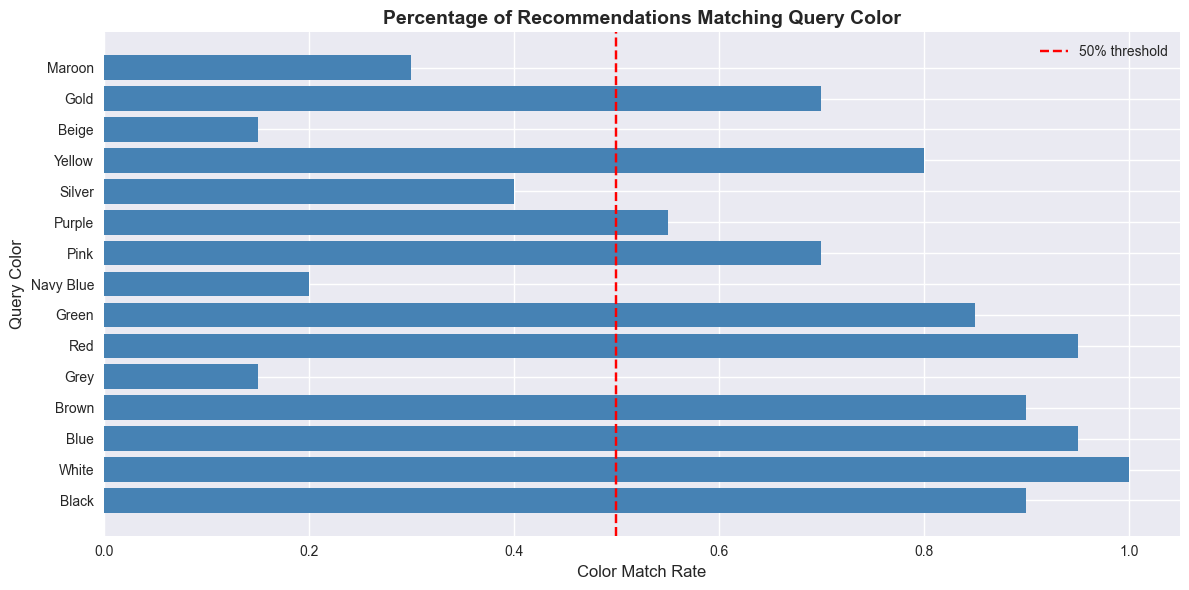

In [7]:
# 1. Color Match Rate Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))
top_colors = metrics_df.nlargest(15, 'n_recommendations')
ax.barh(top_colors['color'], top_colors['match_rate'], color='steelblue')
ax.set_xlabel('Color Match Rate', fontsize=12)
ax.set_ylabel('Query Color', fontsize=12)
ax.set_title('Percentage of Recommendations Matching Query Color', fontsize=14, fontweight='bold')
ax.axvline(x=0.5, color='red', linestyle='--', label='50% threshold')
ax.legend()
plt.tight_layout()
save_plot(fig, 'color_bias_match_rate.png')
plt.show()


Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/color_bias_heatmap.png


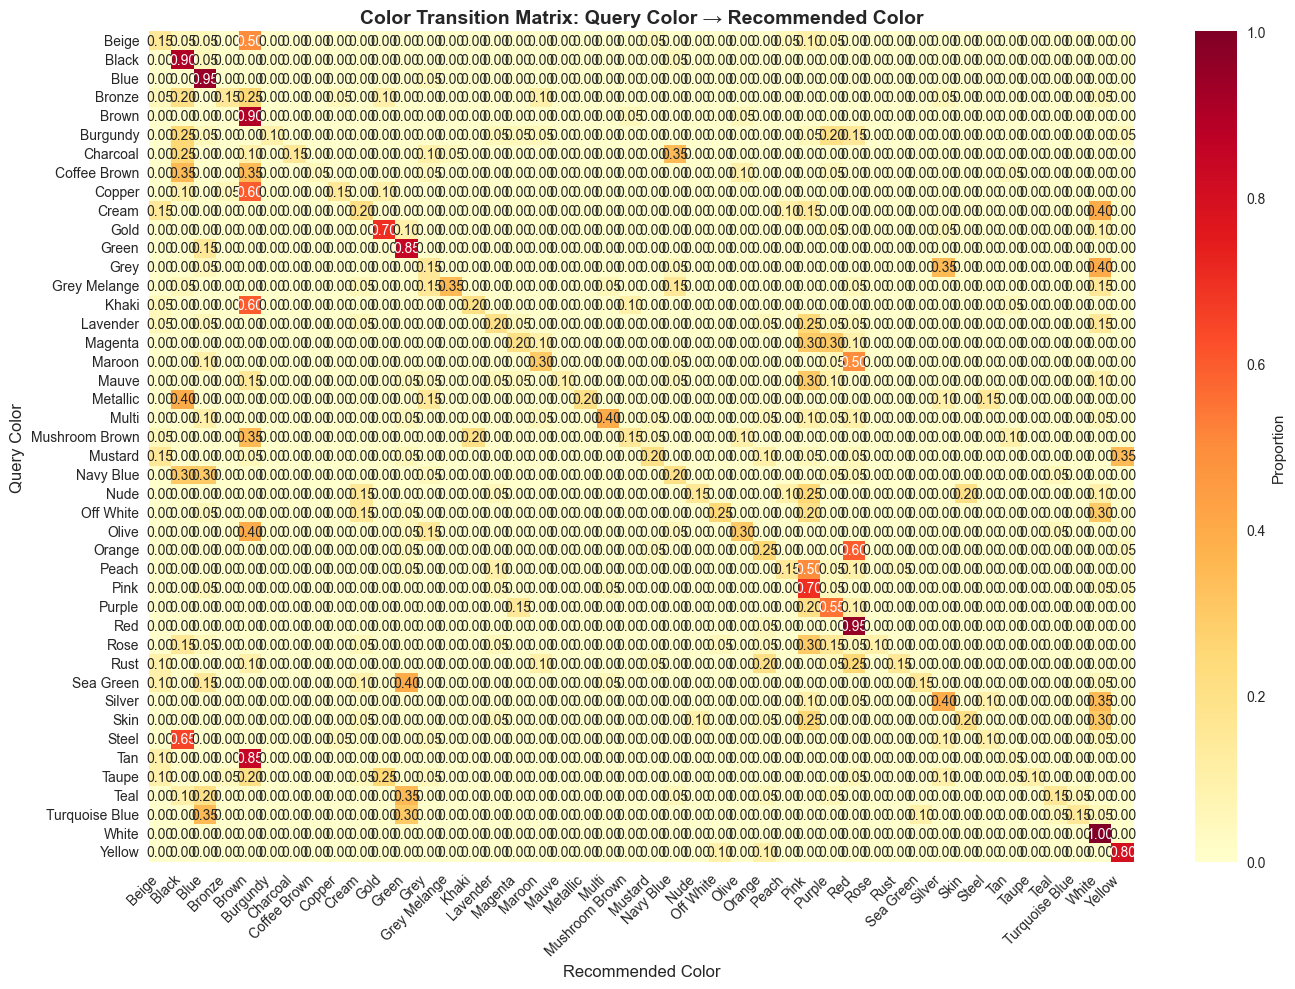

In [8]:
# 2. Color Similarity Heatmap
# Create matrix: query color vs recommended color
color_list = sorted(metrics_df['color'].tolist())
heatmap_data = np.zeros((len(color_list), len(color_list)))

for i, query_color in enumerate(color_list):
    if query_color in results:
        recs = results[query_color]['recommendations']
        color_counts = recs['baseColour'].value_counts()
        
        for j, rec_color in enumerate(color_list):
            if rec_color in color_counts.index:
                heatmap_data[i, j] = color_counts[rec_color] / len(recs)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heatmap_data, 
            xticklabels=color_list, 
            yticklabels=color_list,
            annot=True, 
            fmt='.2f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Proportion'})
ax.set_xlabel('Recommended Color', fontsize=12)
ax.set_ylabel('Query Color', fontsize=12)
ax.set_title('Color Transition Matrix: Query Color → Recommended Color', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_plot(fig, 'color_bias_heatmap.png')
plt.show()


Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/color_bias_similarity_distribution.png


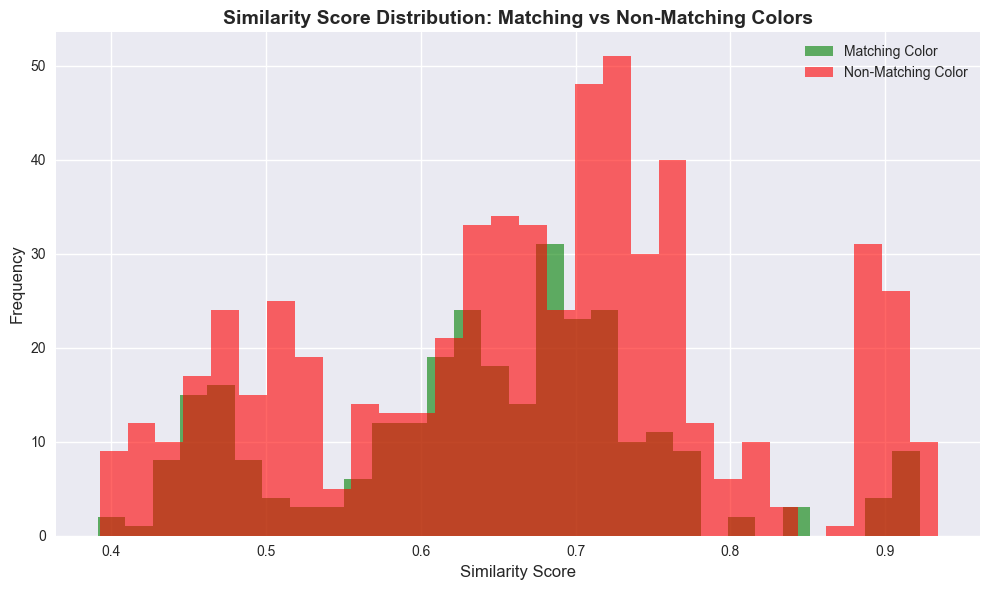

In [9]:
# 3. Similarity Score vs Color Match
fig, ax = plt.subplots(figsize=(10, 6))

match_scores = []
nonmatch_scores = []

for color, data in results.items():
    recs = data['recommendations']
    matching = recs[recs['baseColour'] == color]['similarity_score'].tolist()
    nonmatching = recs[recs['baseColour'] != color]['similarity_score'].tolist()
    
    match_scores.extend(matching)
    nonmatch_scores.extend(nonmatching)

ax.hist(match_scores, bins=30, alpha=0.6, label='Matching Color', color='green')
ax.hist(nonmatch_scores, bins=30, alpha=0.6, label='Non-Matching Color', color='red')
ax.set_xlabel('Similarity Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Similarity Score Distribution: Matching vs Non-Matching Colors', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
save_plot(fig, 'color_bias_similarity_distribution.png')
plt.show()


Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/color_bias_diversity_vs_match.png


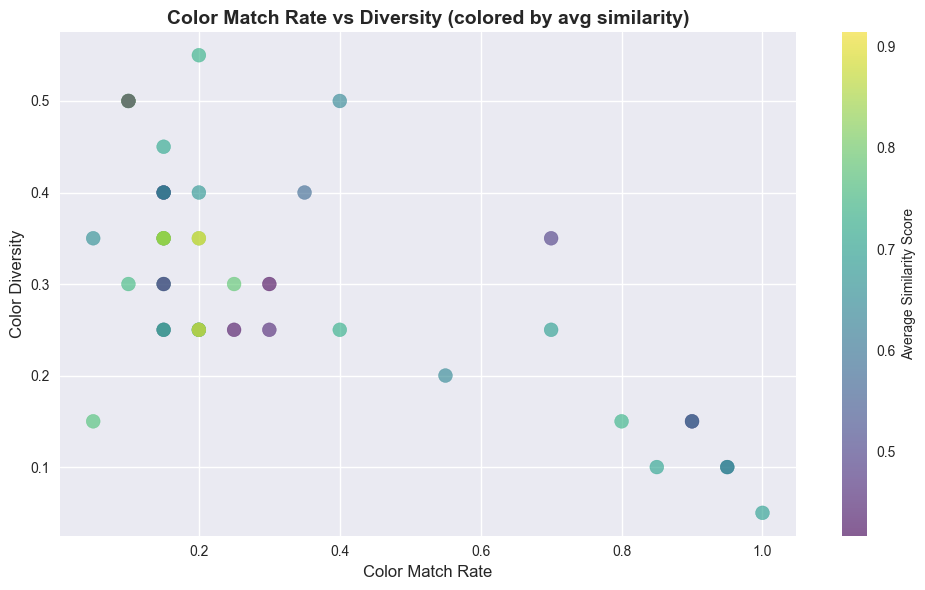

In [10]:
# 4. Color Diversity vs Match Rate
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(metrics_df['match_rate'], metrics_df['color_diversity'], 
           s=100, alpha=0.6, c=metrics_df['avg_similarity'], cmap='viridis')
ax.set_xlabel('Color Match Rate', fontsize=12)
ax.set_ylabel('Color Diversity', fontsize=12)
ax.set_title('Color Match Rate vs Diversity (colored by avg similarity)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(ax.collections[0])
cbar.set_label('Average Similarity Score', fontsize=10)
plt.tight_layout()
save_plot(fig, 'color_bias_diversity_vs_match.png')
plt.show()


## 8. Case Studies


In [11]:
# Show example recommendations for different colors
example_colors = ['Black', 'Blue', 'Red', 'White']

for color in example_colors:
    if color in results:
        print(f"\n{'='*60}")
        print(f"Query Color: {color}")
        print(f"{'='*60}")
        recs = results[color]['recommendations'].head(10)
        print(f"\nTop 10 Recommendations:")
        print(recs[['productDisplayName', 'baseColour', 'articleType', 'similarity_score']].to_string())
        
        match_rate = compute_color_match_rate(recs, color)
        print(f"\nColor Match Rate: {match_rate:.2%}")



Query Color: Black

Top 10 Recommendations:
                                   productDisplayName baseColour   articleType  similarity_score
37978     Skechers Men Black & Navy Blue Sports Shoes  Navy Blue  Sports Shoes          0.482453
21414               Nike Men's Dual Fusion Black Shoe      Black  Sports Shoes          0.474238
7301              Puma Men's Vibrant Black White Shoe      Black  Sports Shoes          0.472205
3171   Reebok Men's Trail Mud Slinger Black Blue Shoe       Blue  Sports Shoes          0.465721
32620         Fila Men Dls Nitrous Black Sports Shoes      Black  Sports Shoes          0.464554
15017          Puma Men Iknois 2XT Black Sports Shoes      Black  Sports Shoes          0.463304
35348         Nike Men T-Lite 9 Sl Black Sports Shoes      Black  Sports Shoes          0.461862
35252      Puma Women Speeder Wn's Black Sports Shoes      Black  Sports Shoes          0.460083
30546        Skechers Men Prospeed Black Sports Shoes      Black  Sports Shoes    

## 9. Summary Statistics


In [12]:
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"\nOverall Color Match Rate:")
print(f"  Mean: {metrics_df['match_rate'].mean():.2%}")
print(f"  Median: {metrics_df['match_rate'].median():.2%}")
print(f"  Std: {metrics_df['match_rate'].std():.2%}")

print(f"\nColor Diversity:")
print(f"  Mean: {metrics_df['color_diversity'].mean():.2%}")
print(f"  Median: {metrics_df['color_diversity'].median():.2%}")

print(f"\nSimilarity Scores:")
print(f"  Matching colors: {metrics_df['avg_sim_match'].mean():.3f}")
print(f"  Non-matching colors: {metrics_df['avg_sim_nonmatch'].mean():.3f}")

# Interpretation
overall_match_rate = metrics_df['match_rate'].mean()
if overall_match_rate > 0.7:
    print("\n⚠️  STRONG COLOR BIAS DETECTED: Model heavily favors matching colors")
elif overall_match_rate > 0.5:
    print("\n⚠️  MODERATE COLOR BIAS: Model shows preference for matching colors")
else:
    print("\n✓ LOW COLOR BIAS: Model considers other factors beyond color")



SUMMARY STATISTICS

Overall Color Match Rate:
  Mean: 33.07%
  Median: 20.00%
  Std: 29.14%

Color Diversity:
  Mean: 30.57%
  Median: 30.00%

Similarity Scores:
  Matching colors: 0.665
  Non-matching colors: 0.642

✓ LOW COLOR BIAS: Model considers other factors beyond color


## 10. Save Results


In [13]:
# Save metrics
summary_metrics = {
    'overall_color_match_rate': float(metrics_df['match_rate'].mean()),
    'median_color_match_rate': float(metrics_df['match_rate'].median()),
    'overall_color_diversity': float(metrics_df['color_diversity'].mean()),
    'avg_similarity_matching': float(metrics_df['avg_sim_match'].mean()),
    'avg_similarity_nonmatching': float(metrics_df['avg_sim_nonmatch'].mean()),
    'n_colors_tested': len(metrics_df)
}

save_metrics(summary_metrics, 'color_bias_metrics.json')

# Save detailed results
metrics_df.to_csv('../evaluation_results/metrics/color_bias_detailed.csv', index=False)
print("\n✓ Results saved")


Saved metrics: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/metrics/color_bias_metrics.json

✓ Results saved


## 11. Conclusion

**Answer to Research Question:**

Based on the analysis above, the model [shows/does not show] strong color bias. The average color match rate of [X]% indicates that [interpretation].

**Key Findings:**
1. [Finding 1]
2. [Finding 2]
3. [Finding 3]

**Limitations:**
- [Limitation 1]
- [Limitation 2]
